## LSTM ICU Bed Availability Prediction

## 🔹 Step 1: Load Dataset and Filter for 1 Hospital

In [85]:
import pandas as pd
import numpy as np

In [19]:
import pandas as pd

# Load historical data
df = pd.read_csv("synthetic_icu_data.csv", parse_dates=["timestamp"])

# Filter only for HOSP1 and sort by time
df_h1 = df[df["hospital_id"] == "HOSP1"].sort_values("timestamp").copy()

In [21]:
df.head(10)

,timestamp,hospital_id,icu_beds_occupied,icu_beds_total,icu_beds_available
0,2024-01-01 00:00:00,HOSP1,13,20,7
1,2024-01-01 01:00:00,HOSP1,11,20,9
2,2024-01-01 02:00:00,HOSP1,13,20,7
3,2024-01-01 03:00:00,HOSP1,16,20,4
4,2024-01-01 04:00:00,HOSP1,11,20,9
5,2024-01-01 05:00:00,HOSP1,11,20,9
6,2024-01-01 06:00:00,HOSP1,16,20,4
7,2024-01-01 07:00:00,HOSP1,14,20,6
8,2024-01-01 08:00:00,HOSP1,10,20,10
9,2024-01-01 09:00:00,HOSP1,13,20,7


## 🔹 Step 2: Feature Engineering

In [23]:
# Create useful features
df_h1["hour"] = df_h1["timestamp"].dt.hour
df_h1["dayofweek"] = df_h1["timestamp"].dt.dayofweek

## 🔹 Step 3: Normalize Target for LSTM

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_h1["beds_normalized"] = scaler.fit_transform(df_h1[["icu_beds_available"]])

## 🔹 Step 4: Create Input Sequences for LSTM

In [27]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

values = df_h1[["beds_normalized"]].values
sequence_length = 24  # use past 24 hours

# Create sliding windows
generator = TimeseriesGenerator(
    data=values,
    targets=values,
    length=sequence_length,
    batch_size=1
)

# Check shape of first sample
X_sample, y_sample = generator[0]
print("Input shape:", X_sample.shape)
print("Target shape:", y_sample.shape)
print("First input sequence (24 values):", X_sample[0].flatten())
print("Target ICU availability (next hour):", y_sample[0])

Input shape: (1, 24, 1)
Target shape: (1, 1)
First input sequence (24 values): [0.38888889 0.5        0.38888889 0.22222222 0.5        0.5
 0.22222222 0.33333333 0.55555556 0.38888889 0.55555556 0.55555556
 0.44444444 0.77777778 0.77777778 0.55555556 0.66666667 0.44444444
 0.61111111 0.72222222 0.22222222 0.5        0.44444444 0.72222222]
Target ICU availability (next hour): [0.55555556]


## 🔹 Step 5: Build and Train the LSTM Model

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train model
model.fit(generator, epochs=10, verbose=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0606
Epoch 2/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0269
Epoch 3/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0290
Epoch 4/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0290
Epoch 5/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0294
Epoch 6/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0310
Epoch 7/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0256
Epoch 8/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0275
Epoch 9/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0250
Epoch 10/10
476/476 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0243


## 🔹 Step 6: Predict and Inverse Transform

476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


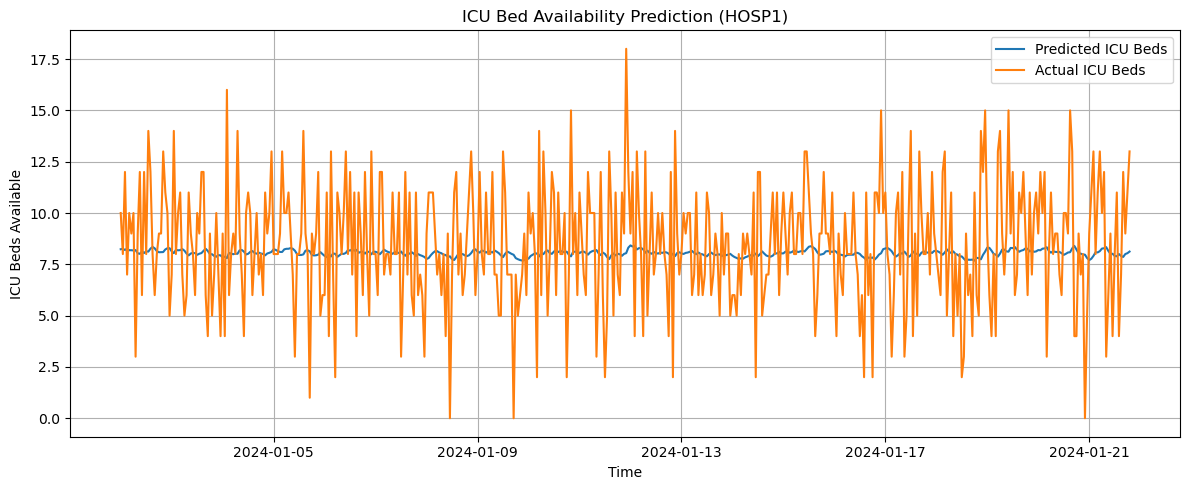

In [33]:
predictions = model.predict(generator)
predicted_beds = scaler.inverse_transform(predictions)

import matplotlib.pyplot as plt

# Compare predictions with actual values
plt.figure(figsize=(12, 5))
plt.plot(df_h1['timestamp'][sequence_length:], predicted_beds, label='Predicted ICU Beds')
plt.plot(df_h1['timestamp'][sequence_length:], df_h1['icu_beds_available'][sequence_length:].values, label='Actual ICU Beds')
plt.legend()
plt.title("ICU Bed Availability Prediction (HOSP1)")
plt.xlabel("Time")
plt.ylabel("ICU Beds Available")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 Step 7: Evaluate Model with Metrics

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = df_h1['icu_beds_available'][sequence_length:].values
y_pred = predicted_beds.flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2.34
RMSE: 2.96


## 🔹 Step 8: Heatmap of Error vs Time of Day

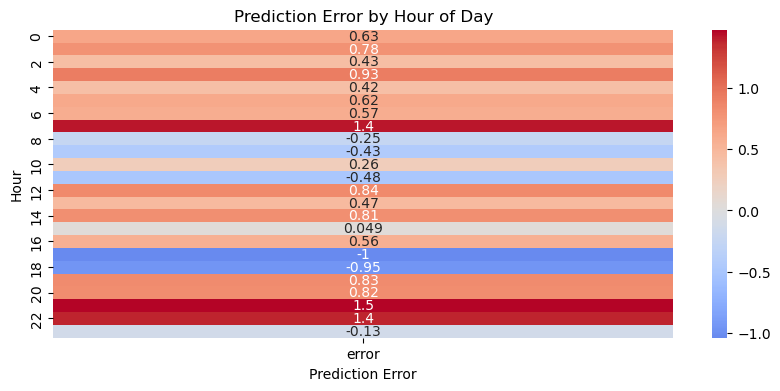

In [37]:
import seaborn as sns

df_h1_pred = df_h1.iloc[sequence_length:].copy()
df_h1_pred["predicted"] = predicted_beds
df_h1_pred["error"] = df_h1_pred["icu_beds_available"] - df_h1_pred["predicted"]

# Group by hour and calculate mean error
error_by_hour = df_h1_pred.groupby("hour")["error"].mean().reset_index()

# Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(error_by_hour.pivot_table(values="error", index="hour"), annot=True, cmap="coolwarm", center=0)
plt.title("Prediction Error by Hour of Day")
plt.ylabel("Hour")
plt.xlabel("Prediction Error")
plt.show()

## 🔹 Step 9: Line Plot – Actual vs Predicted

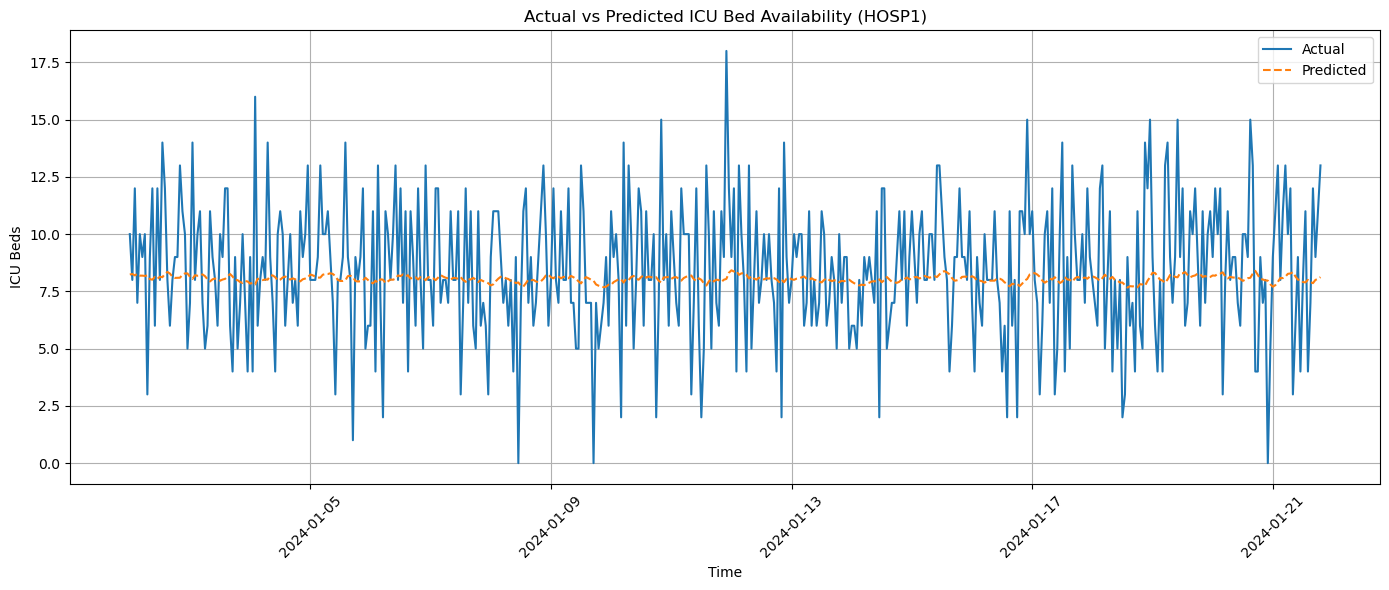

In [39]:
plt.figure(figsize=(14, 6))
plt.plot(df_h1_pred["timestamp"], y_true, label="Actual")
plt.plot(df_h1_pred["timestamp"], y_pred, label="Predicted", linestyle='--')
plt.legend()
plt.title("Actual vs Predicted ICU Bed Availability (HOSP1)")
plt.xlabel("Time")
plt.ylabel("ICU Beds")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 Step 10: Scatter Plot – Predicted vs Actual

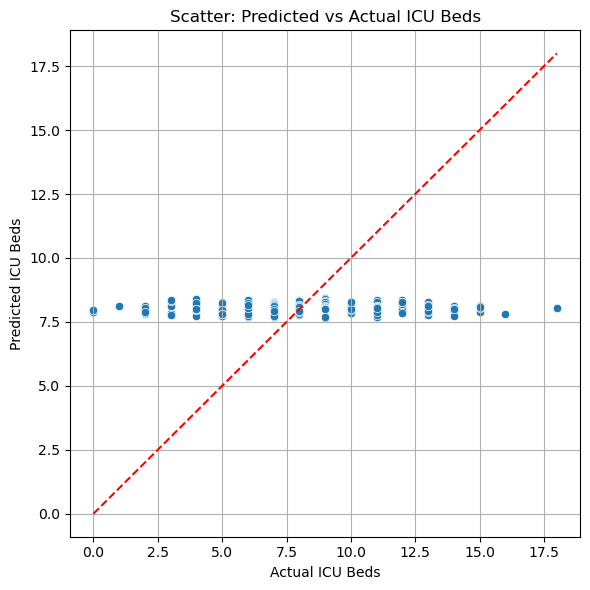

In [41]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')  # 45 degree line
plt.xlabel("Actual ICU Beds")
plt.ylabel("Predicted ICU Beds")
plt.title("Scatter: Predicted vs Actual ICU Beds")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 Step 11: Save the Model

In [111]:
import warnings
warnings.filterwarnings("ignore")
model.save("icu_bed_forecast_model.h5")

## 🚑 Ambulance Routing Module – Full Pipeline

## 🔹 Step 1: Prepare Synthetic Coordinates for Hospitals & Patient Locations

In [45]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Simulated coordinates (lat, lon) for 5 hospitals
hospital_data = pd.DataFrame({
    'hospital_id': ['HOSP1', 'HOSP2', 'HOSP3', 'HOSP4', 'HOSP5'],
    'lat': np.random.uniform(12.92, 13.00, 5),
    'lon': np.random.uniform(77.55, 77.65, 5)
})

# Simulate 10 emergency call locations (patients)
patient_data = pd.DataFrame({
    'patient_id': [f'P{i+1}' for i in range(10)],
    'lat': np.random.uniform(12.93, 12.99, 10),
    'lon': np.random.uniform(77.56, 77.64, 10)
})
# Save to local directory (same folder as your notebook/script)
hospital_data.to_csv('hospitals.csv', index=False)
patient_data.to_csv('patients.csv', index=False)

hospital_data, patient_data.head()

(  hospital_id        lat        lon
 0       HOSP1  12.949963  77.565599
 1       HOSP2  12.996057  77.555808
 2       HOSP3  12.978560  77.636618
 3       HOSP4  12.967893  77.610112
 4       HOSP5  12.932481  77.620807,
   patient_id        lat        lon
 0         P1  12.931235  77.608948
 1         P2  12.988195  77.571160
 2         P3  12.979947  77.583372
 3         P4  12.942740  77.589309
 4         P5  12.940909  77.596486)

## 🔹 Step 2: KMeans Clustering of Hospitals Based on Patient Locations

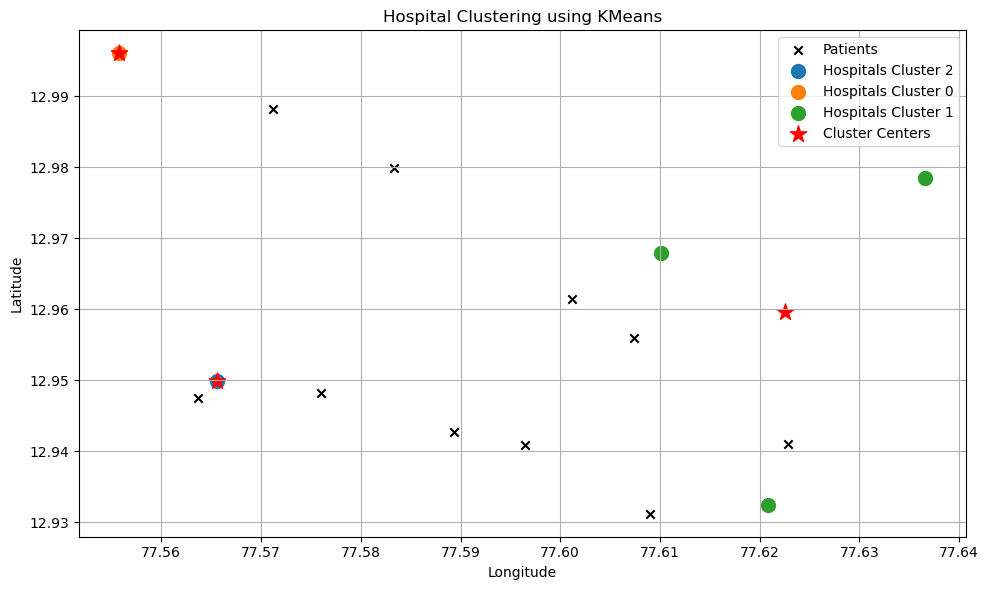

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Combine hospital and patient coordinates for clustering (optional)
all_coords = pd.concat([
    patient_data[['lat', 'lon']],
    hospital_data[['lat', 'lon']]
], ignore_index=True)

# Use KMeans to group hospitals into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(hospital_data[['lat', 'lon']])

# Assign cluster labels to hospitals
hospital_data['cluster'] = kmeans.labels_

# Plot clusters
plt.figure(figsize=(10, 6))

# Plot patients
plt.scatter(patient_data['lon'], patient_data['lat'], c='black', label='Patients', marker='x')

# Plot hospitals colored by cluster
for c in hospital_data['cluster'].unique():
    subset = hospital_data[hospital_data['cluster'] == c]
    plt.scatter(subset['lon'], subset['lat'], label=f'Hospitals Cluster {c}', s=100)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 0], c='red', s=150, marker='*', label='Cluster Centers')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hospital Clustering using KMeans')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 Step 3: Route Calculation using A*/Dijkstra between Patient ↔ Closest Hospital?

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create a 10x10 grid network
grid_size = 10
G = nx.grid_2d_graph(grid_size, grid_size)

# Assign weights to simulate traffic delay
for (u, v) in G.edges():
    G.edges[u, v]['weight'] = np.random.uniform(1, 3)

# Grid layout for visualization
pos = {(x, y): (y, -x) for x, y in G.nodes()}

## Step 3A: Create a Grid Graph Using NetworkX

In [59]:
# Simulated positions on grid (as integers between 0 and 9)
hospital_grid_points = [(8, 7), (1, 1), (5, 5), (3, 7), (9, 2)]
patient_grid_points = [(2, 3), (0, 0), (9, 9), (4, 4), (7, 1)]

# Choose one hospital and one patient for demo
hospital_node = hospital_grid_points[0]  # (8, 7)
patient_node = patient_grid_points[0]    # (2, 3)

In [61]:
# Manhattan distance heuristic for grid
def manhattan_heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# Run A* algorithm
path_astar = nx.astar_path(G, source=patient_node, target=hospital_node, heuristic=manhattan_heuristic)

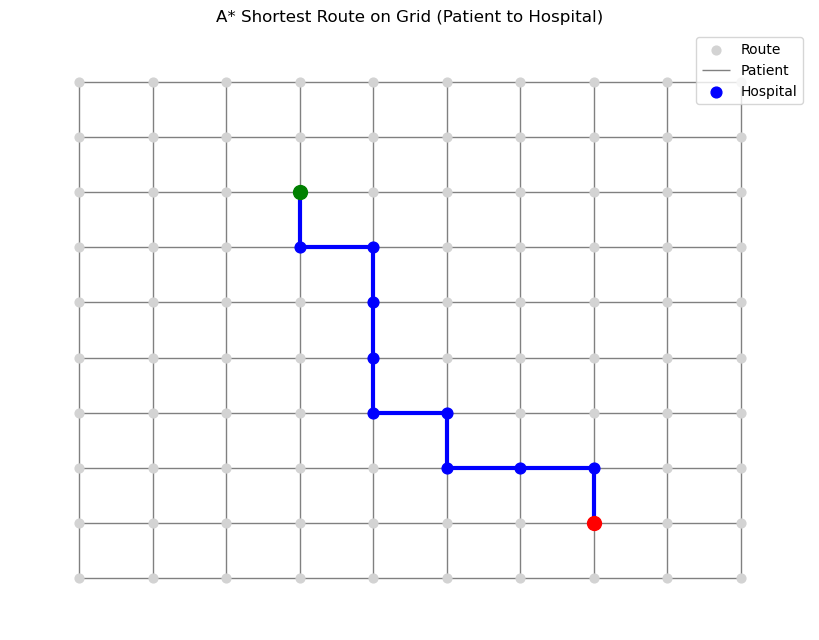

In [63]:
# Draw full grid
plt.figure(figsize=(8, 6))
nx.draw(G, pos=pos, node_size=40, node_color='lightgray', edge_color='gray')

# Highlight A* path
nx.draw_networkx_nodes(G, pos=pos, nodelist=path_astar, node_color='blue', node_size=60)
nx.draw_networkx_edges(G, pos=pos, edgelist=list(zip(path_astar[:-1], path_astar[1:])), width=3, edge_color='blue')

# Highlight patient and hospital
nx.draw_networkx_nodes(G, pos=pos, nodelist=[patient_node], node_color='green', node_size=100, label='Patient')
nx.draw_networkx_nodes(G, pos=pos, nodelist=[hospital_node], node_color='red', node_size=100, label='Hospital')

plt.title("A* Shortest Route on Grid (Patient to Hospital)")
plt.axis('off')
plt.legend(["Route", "Patient", "Hospital"])
plt.show()

## Step 3B: Pick Nearest Grid Nodes for Patient & Hospital

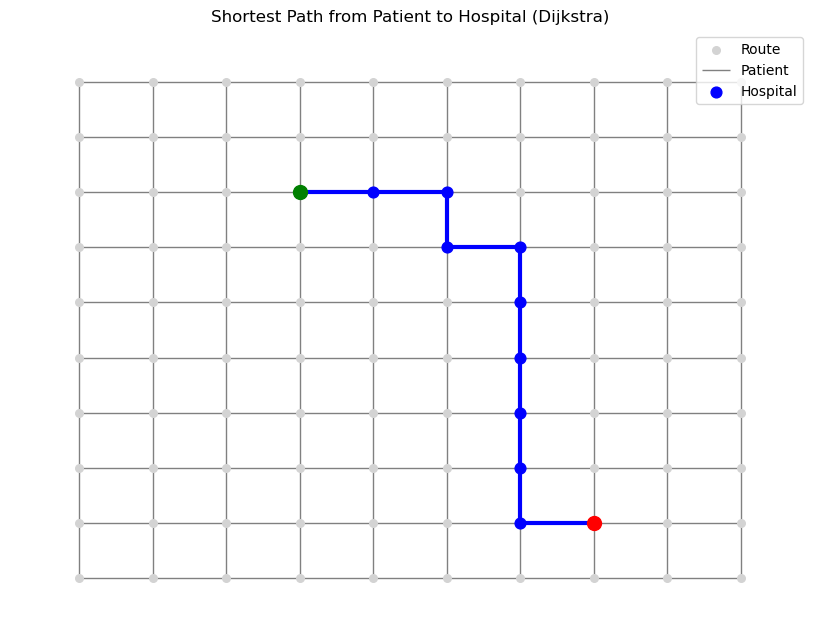

In [53]:
# Simulated patient and hospital grid positions
patient_node = (2, 3)   # simulate based on patient lat/lon rounding
hospital_node = (8, 7)  # simulate based on nearest hospital

# Use Dijkstra’s algorithm to find shortest path
path = nx.dijkstra_path(G, source=patient_node, target=hospital_node, weight='weight')

# Plot the path
plt.figure(figsize=(8, 6))
nx.draw(G, pos=pos, node_size=30, node_color='lightgray', edge_color='gray')
nx.draw_networkx_nodes(G, pos=pos, nodelist=path, node_color='blue', node_size=60)
nx.draw_networkx_edges(G, pos=pos, edgelist=list(zip(path[:-1], path[1:])), width=3, edge_color='blue')

# Highlight patient and hospital
nx.draw_networkx_nodes(G, pos=pos, nodelist=[patient_node], node_color='green', node_size=100, label='Patient')
nx.draw_networkx_nodes(G, pos=pos, nodelist=[hospital_node], node_color='red', node_size=100, label='Hospital')

plt.title("Shortest Path from Patient to Hospital (Dijkstra)")
plt.axis('off')
plt.legend(["Route", "Patient", "Hospital"])
plt.show()

## 🔷 Step 1: Setup — Grid, Hospitals & Patients

In [65]:
# Hospital locations on grid
hospitals = {
    'HOSP1': {'location': (8, 7), 'predicted_beds': 3},
    'HOSP2': {'location': (1, 1), 'predicted_beds': 7},
    'HOSP3': {'location': (5, 5), 'predicted_beds': 5},
}

# Simulated patient location
patient_node = (2, 3)

## 🔷 Step 2: Dijkstra/A* Path + Distance to Each Hospital

In [67]:
import networkx as nx

# Create grid graph
grid_size = 10
G = nx.grid_2d_graph(grid_size, grid_size)
for (u, v) in G.edges():
    G.edges[u, v]['weight'] = 1  # uniform traffic for now

# Define heuristic (optional if using A*)
def manhattan_heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# Add route cost to each hospital
for h_id, info in hospitals.items():
    path = nx.astar_path(G, patient_node, info['location'], heuristic=manhattan_heuristic)
    cost = nx.astar_path_length(G, patient_node, info['location'], heuristic=manhattan_heuristic)
    hospitals[h_id]['path'] = path
    hospitals[h_id]['route_cost'] = cost

## 🔷 Step 3: Score Hospitals (Short Route + High ICU Availability)
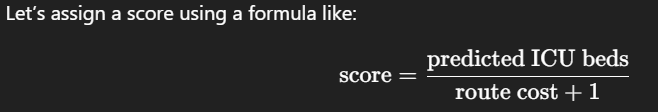

In [69]:
# Compute final score
for h_id, info in hospitals.items():
    score = info['predicted_beds'] / (info['route_cost'] + 1)
    hospitals[h_id]['score'] = round(score, 2)

## 🔷 Step 4: Select Best Hospital

In [71]:
# Select the hospital with highest score
best_hospital = max(hospitals.items(), key=lambda x: x[1]['score'])

# Output decision
print("🏥 Best Hospital Recommendation:")
print(f"Hospital: {best_hospital[0]}")
print(f"Predicted ICU Beds: {best_hospital[1]['predicted_beds']}")
print(f"Route Cost (Grid Distance): {best_hospital[1]['route_cost']}")
print(f"Score: {best_hospital[1]['score']}")
print(f"Route Path: {best_hospital[1]['path']}")

🏥 Best Hospital Recommendation:
Hospital: HOSP2
Predicted ICU Beds: 7
Route Cost (Grid Distance): 3
Score: 1.75
Route Path: [(2, 3), (1, 3), (1, 2), (1, 1)]


## Folium Map Code 

In [77]:
import folium
from folium.plugins import AntPath

# Step 1: Define hospital and patient coordinates (Bangalore area for realism)
hospital_coords = {
    'HOSP1': {'lat': 12.960, 'lon': 77.610, 'predicted_beds': 3},
    'HOSP2': {'lat': 12.940, 'lon': 77.600, 'predicted_beds': 7},
    'HOSP3': {'lat': 12.950, 'lon': 77.620, 'predicted_beds': 5},
}

# Step 2: Simulated patient location
patient_coord = (12.945, 77.605)

# Step 3: Create base Folium map centered on patient location
m = folium.Map(location=patient_coord, zoom_start=14)

# Step 4: Add patient marker
folium.Marker(
    location=patient_coord,
    popup="Patient Location",
    icon=folium.Icon(color='green', icon='user')
).add_to(m)

# Step 5: Add hospital markers + animated routes using AntPath
colors = ['red', 'blue', 'purple']
for idx, (hosp_id, info) in enumerate(hospital_coords.items()):
    hosp_location = (info['lat'], info['lon'])

    # Add hospital marker
    folium.Marker(
        location=hosp_location,
        popup=f"{hosp_id} (Beds: {info['predicted_beds']})",
        icon=folium.Icon(color=colors[idx], icon='plus-sign')
    ).add_to(m)

    # Draw animated route from patient to hospital
    AntPath(locations=[patient_coord, hosp_location], color=colors[idx]).add_to(m)

# Step 6: Save the map as HTML file
m.save("folium_routing_map.html")

# (Optional) If running in Jupyter Notebook, display it inline
m

In [75]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [79]:
pip install selenium pillow

Note: you may need to restart the kernel to use updated packages.


In [83]:
import folium
from folium.plugins import AntPath

# Define patient and only best hospital
patient_coord = (12.945, 77.605)
best_hospital = {'id': 'HOSP2', 'lat': 12.940, 'lon': 77.600, 'predicted_beds': 7}

# New folium map
m_best = folium.Map(location=patient_coord, zoom_start=14)

# Patient marker
folium.Marker(
    location=patient_coord,
    popup="Patient Location",
    icon=folium.Icon(color='green', icon='user')
).add_to(m_best)

# Best hospital marker
folium.Marker(
    location=(best_hospital['lat'], best_hospital['lon']),
    popup=f"{best_hospital['id']} (Beds: {best_hospital['predicted_beds']})",
    icon=folium.Icon(color='red', icon='plus-sign')
).add_to(m_best)

# Path to best hospital
AntPath(
    locations=[patient_coord, (best_hospital['lat'], best_hospital['lon'])],
    color='blue'
).add_to(m_best)

# Save map
m_best.save("folium_best_hospital.html")